# RF-DETR Evaluation

Evaluates a trained RF-DETR checkpoint on the LARS validation set.

## Contents
1. [Setup](#1-setup)
2. [Training Curves](#2-training-curves) — loss, mAP, precision/recall/F1, per-class AP
3. [Confusion Matrix](#3-confusion-matrix) — IoU-based matching on the full validation set
4. [Misclassification Visualizations](#4-misclassification-visualizations) — wrong-class crops, false positives, false negatives

## 1. Setup

In [17]:
from pathlib import Path
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
import torch
from tqdm.notebook import tqdm
import supervision as sv
from rfdetr import RFDETRBase

# ── Configuration ─────────────────────────────────────────────────────────────
RUNS_DIR   = Path("../runs/rfdetr_v3")  # change to your run directory
DATA_ROOT  = Path("../Data/lars_processed")
THRESHOLD  = 0.3    # confidence threshold for inference
IOU_THRESH = 0.5    # IoU threshold for TP/FP matching

random.seed(4)
np.random.seed(4)

In [18]:
# Load validation annotations
ann_val = json.load(open(DATA_ROOT / "valid" / "_annotations.coco.json"))

val_img_meta  = {img["id"]: img for img in ann_val["images"]}
val_ann_by_id = {}
for a in ann_val["annotations"]:
    val_ann_by_id.setdefault(a["image_id"], []).append(a)

categories  = ann_val["categories"]
CLASS_IDS   = [c["id"]   for c in categories]
CLASS_NAMES = [c["name"] for c in categories]
id_to_idx   = {cid: i for i, cid in enumerate(CLASS_IDS)}
N_CLASSES   = len(CLASS_IDS)

print(f"Validation: {len(ann_val['images'])} images, {len(ann_val['annotations'])} annotations")
print(f"Classes ({N_CLASSES}):")
for cid, name in zip(CLASS_IDS, CLASS_NAMES):
    count = sum(1 for a in ann_val["annotations"] if a["category_id"] == cid)
    print(f"  [{cid:2d}] {name:<20} {count:4d} instances")

Validation: 198 images, 1107 annotations
Classes (8):
  [11] Boat/ship             786 instances
  [12] Row boats              34 instances
  [13] Paddle board           30 instances
  [14] Buoy                  125 instances
  [15] Swimmer                26 instances
  [16] Animal                 30 instances
  [17] Float                   3 instances
  [19] Other                  73 instances


In [19]:
# Load the best checkpoint
best_ckpt = RUNS_DIR / "checkpoint_best_total.pth"
if not best_ckpt.exists():
    candidates = sorted(RUNS_DIR.glob("checkpoint_best*.pth"))
    best_ckpt  = candidates[-1] if candidates else None
if best_ckpt is None:
    raise FileNotFoundError(f"No checkpoint found in {RUNS_DIR}. Run train_rfdetr.py first.")

model = RFDETRBase(resolution=560, num_classes=N_CLASSES, pretrain_weights=None)
state = torch.load(best_ckpt, map_location="cpu")
model.model.model.load_state_dict(state["model"])
print(f"Loaded checkpoint : {best_ckpt.name}")
print(f"Device            : {'CUDA — ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Loaded checkpoint : checkpoint_best_total.pth
Device            : CUDA — NVIDIA GeForce RTX 4080 Laptop GPU


---
## 2. Training Curves

Loaded from `metrics.csv` written by the training script.

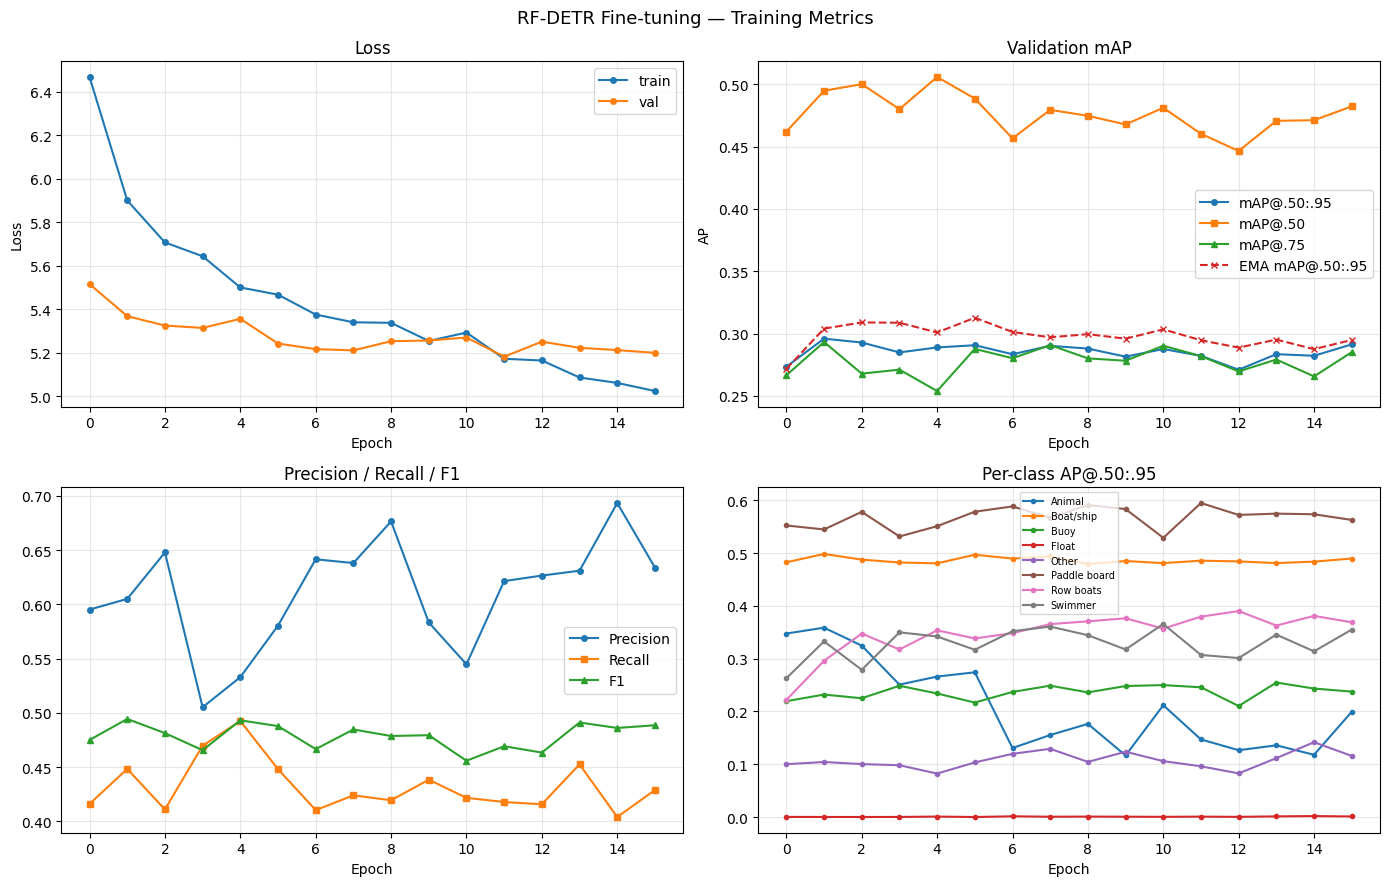


Best epoch  : 1
  mAP@.50:.95 = 0.2959
  mAP@.50     = 0.4947
  mAP@.75     = 0.2932
  Precision   = 0.6050
  Recall      = 0.4483
  F1          = 0.4944


In [20]:
metrics_path = RUNS_DIR / "metrics.csv"
if not metrics_path.exists():
    raise FileNotFoundError(f"metrics.csv not found in {RUNS_DIR}")

df = pd.read_csv(metrics_path)

val_df   = df.dropna(subset=["val/mAP_50_95"]).copy()
train_df = df.dropna(subset=["train/loss"]).copy()

# One row per epoch: join val metrics with train loss
val_cols = ["epoch", "val/loss", "val/mAP_50_95", "val/mAP_50", "val/mAP_75",
            "val/ema_mAP_50_95", "val/precision", "val/recall", "val/F1"]
merged = pd.merge(
    val_df[val_cols],
    train_df[["epoch", "train/loss"]],
    on="epoch", how="left"
).sort_values("epoch").reset_index(drop=True)

epochs = merged["epoch"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Loss
ax = axes[0, 0]
ax.plot(epochs, merged["train/loss"], marker="o", ms=4, label="train")
ax.plot(epochs, merged["val/loss"],   marker="o", ms=4, label="val")
ax.set_title("Loss"); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(); ax.grid(alpha=0.3)

# mAP
ax = axes[0, 1]
ax.plot(epochs, merged["val/mAP_50_95"],    marker="o",  ms=4, label="mAP@.50:.95")
ax.plot(epochs, merged["val/mAP_50"],        marker="s",  ms=4, label="mAP@.50")
ax.plot(epochs, merged["val/mAP_75"],        marker="^",  ms=4, label="mAP@.75")
ax.plot(epochs, merged["val/ema_mAP_50_95"], marker="x",  ms=5, ls="--", label="EMA mAP@.50:.95")
ax.set_title("Validation mAP"); ax.set_xlabel("Epoch"); ax.set_ylabel("AP")
ax.legend(); ax.grid(alpha=0.3)

# Precision / Recall / F1
ax = axes[1, 0]
ax.plot(epochs, merged["val/precision"], marker="o", ms=4, label="Precision")
ax.plot(epochs, merged["val/recall"],    marker="s", ms=4, label="Recall")
ax.plot(epochs, merged["val/F1"],        marker="^", ms=4, label="F1")
ax.set_title("Precision / Recall / F1"); ax.set_xlabel("Epoch")
ax.legend(); ax.grid(alpha=0.3)

# Per-class AP
ax = axes[1, 1]
class_ap_cols = [c for c in val_df.columns if c.startswith("val/AP/")]
for col in class_ap_cols:
    ax.plot(val_df["epoch"], val_df[col], marker="o", ms=3, label=col.replace("val/AP/", ""))
ax.set_title("Per-class AP@.50:.95"); ax.set_xlabel("Epoch")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.suptitle("RF-DETR Fine-tuning — Training Metrics", fontsize=13)
plt.tight_layout()
plt.savefig(RUNS_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary table
best = merged.loc[merged["val/mAP_50_95"].idxmax()]
print(f"\nBest epoch  : {int(best['epoch'])}")
print(f"  mAP@.50:.95 = {best['val/mAP_50_95']:.4f}")
print(f"  mAP@.50     = {best['val/mAP_50']:.4f}")
print(f"  mAP@.75     = {best['val/mAP_75']:.4f}")
print(f"  Precision   = {best['val/precision']:.4f}")
print(f"  Recall      = {best['val/recall']:.4f}")
print(f"  F1          = {best['val/F1']:.4f}")

---
## 3. Confusion Matrix

For every validation image:
1. Predictions are matched to ground-truth boxes by **IoU ≥ 0.5** (greedy, highest-confidence first).
2. Matched pair with same class → **TP**; different class → **wrong-class** entry.
3. Unmatched GT → **FN** (missed object, mapped to *Background* column).
4. Unmatched prediction → **FP** (spurious detection, mapped to *Background* row).

Matrix rows = actual (GT), columns = predicted.

In [21]:
# ── Helper functions ──────────────────────────────────────────────────────────

def box_iou(a, b):
    """IoU between two boxes in xyxy format."""
    xi1, yi1 = max(a[0], b[0]), max(a[1], b[1])
    xi2, yi2 = min(a[2], b[2]), min(a[3], b[3])
    inter    = max(0.0, xi2 - xi1) * max(0.0, yi2 - yi1)
    area_a   = (a[2] - a[0]) * (a[3] - a[1])
    area_b   = (b[2] - b[0]) * (b[3] - b[1])
    union    = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


def match_detections(pred_det, gt_det, iou_thresh=0.5):
    """
    Greedy IoU matching (predictions sorted by descending confidence).

    Returns
    -------
    matched  : list of (gt_class, pred_class, pred_score, pred_box, gt_box)
    fn_list  : list of (gt_box, gt_class)  — unmatched GT objects
    fp_list  : list of (pred_box, pred_class, pred_score) — spurious predictions
    """
    pred_boxes   = pred_det.xyxy       if len(pred_det) > 0 else np.empty((0, 4))
    pred_classes = pred_det.class_id   if len(pred_det) > 0 else np.array([], dtype=int)
    pred_scores  = (pred_det.confidence
                    if pred_det.confidence is not None and len(pred_det) > 0
                    else np.ones(len(pred_det)))
    gt_boxes     = gt_det.xyxy         if len(gt_det) > 0 else np.empty((0, 4))
    gt_classes   = gt_det.class_id     if len(gt_det) > 0 else np.array([], dtype=int)

    if len(pred_boxes) == 0:
        return [], [(gt_boxes[i], gt_classes[i]) for i in range(len(gt_boxes))], []
    if len(gt_boxes) == 0:
        return [], [], [(pred_boxes[i], pred_classes[i], pred_scores[i])
                        for i in range(len(pred_boxes))]

    order        = np.argsort(-pred_scores)
    pred_boxes   = pred_boxes[order]
    pred_classes = pred_classes[order]
    pred_scores  = pred_scores[order]

    matched_gt, matched_pred = {}, {}
    for pi, (pb, pc, ps) in enumerate(zip(pred_boxes, pred_classes, pred_scores)):
        best_iou, best_gi = iou_thresh, -1
        for gi in range(len(gt_boxes)):
            if gi in matched_gt:
                continue
            iou = box_iou(pb, gt_boxes[gi])
            if iou > best_iou:
                best_iou, best_gi = iou, gi
        if best_gi >= 0:
            matched_gt[best_gi]  = pi
            matched_pred[pi]     = best_gi

    matched = [
        (gt_classes[gi], pred_classes[pi], pred_scores[pi], pred_boxes[pi], gt_boxes[gi])
        for gi, pi in matched_gt.items()
    ]
    fn_list = [(gt_boxes[i], gt_classes[i])
               for i in range(len(gt_boxes)) if i not in matched_gt]
    fp_list = [(pred_boxes[i], pred_classes[i], pred_scores[i])
               for i in range(len(pred_boxes)) if i not in matched_pred]

    return matched, fn_list, fp_list

In [22]:
# Run inference on the full validation set
all_gt_dets   = []
all_pred_dets = []
img_id_order  = list(val_img_meta.keys())   # preserve insertion order

for img_id in tqdm(img_id_order, desc="Inference"):
    meta    = val_img_meta[img_id]
    pil_img = Image.open(DATA_ROOT / "valid" / meta["file_name"]).convert("RGB")
    gt_anns = val_ann_by_id.get(img_id, [])

    if gt_anns:
        gt_xyxy  = np.array([[a["bbox"][0], a["bbox"][1],
                               a["bbox"][0] + a["bbox"][2],
                               a["bbox"][1] + a["bbox"][3]] for a in gt_anns], dtype=float)
        gt_cids  = np.array([a["category_id"] for a in gt_anns], dtype=int)
    else:
        gt_xyxy, gt_cids = np.empty((0, 4), dtype=float), np.array([], dtype=int)

    all_gt_dets.append(sv.Detections(xyxy=gt_xyxy, class_id=gt_cids))
    all_pred_dets.append(model.predict(pil_img, threshold=THRESHOLD))

print(f"Inference complete on {len(all_pred_dets)} images.")

Inference:   0%|          | 0/198 [00:00<?, ?it/s]

[2026-04-10 08:29:30] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


Inference complete on 198 images.


In [23]:
# Determine whether predictions use original COCO IDs or 0-indexed IDs
sample_ids = set()
for pred in all_pred_dets:
    if len(pred) > 0:
        sample_ids.update(pred.class_id.tolist())
        break

if sample_ids and max(sample_ids) <= N_CLASSES - 1:
    pred_to_idx = {i: i for i in range(N_CLASSES)}   # already 0-indexed
    print("Predictions: 0-indexed class IDs")
else:
    pred_to_idx = id_to_idx                            # original COCO IDs
    print("Predictions: original COCO category IDs")

def pred_class_name(cid):
    idx = pred_to_idx.get(int(cid), -1)
    return CLASS_NAMES[idx] if 0 <= idx < N_CLASSES else str(cid)

def gt_class_name(cid):
    idx = id_to_idx.get(int(cid), -1)
    return CLASS_NAMES[idx] if 0 <= idx < N_CLASSES else str(cid)

# Build confusion matrix — rows = GT class, cols = predicted class, last = background
cm = np.zeros((N_CLASSES + 1, N_CLASSES + 1), dtype=int)

# Collect misclassification examples for later visualisation
wrong_class_examples = []   # (img_path, pred_box, pred_cls, pred_score, gt_box, gt_cls)
fp_by_image          = {}   # img_path → [(pred_box, pred_cls, score), ...]
fn_by_image          = {}   # img_path → [(gt_box, gt_cls), ...]

for idx, img_id in enumerate(img_id_order):
    img_path = DATA_ROOT / "valid" / val_img_meta[img_id]["file_name"]
    matched, fn_list, fp_list = match_detections(
        all_pred_dets[idx], all_gt_dets[idx], IOU_THRESH
    )

    for gc, pc, ps, pb, gb in matched:
        gi = id_to_idx.get(int(gc), -1)
        pi = pred_to_idx.get(int(pc), -1)
        if gi >= 0 and pi >= 0:
            cm[gi, pi] += 1
            if gi != pi:
                wrong_class_examples.append((img_path, pb, pc, ps, gb, gc))

    for gb, gc in fn_list:
        gi = id_to_idx.get(int(gc), -1)
        if gi >= 0:
            cm[gi, N_CLASSES] += 1
    if fn_list:
        fn_by_image[img_path] = fn_list

    for pb, pc, ps in fp_list:
        pi = pred_to_idx.get(int(pc), -1)
        if pi >= 0:
            cm[N_CLASSES, pi] += 1
    if fp_list:
        fp_by_image[img_path] = fp_list

print(f"Total GT objects      : {cm[:-1, :].sum()}")
print(f"True positives        : {np.diag(cm[:N_CLASSES, :N_CLASSES]).sum()}")
print(f"Wrong-class           : {cm[:N_CLASSES, :N_CLASSES].sum() - np.diag(cm[:N_CLASSES, :N_CLASSES]).sum()}")
print(f"False negatives (FN)  : {cm[:N_CLASSES, N_CLASSES].sum()}")
print(f"False positives (FP)  : {cm[N_CLASSES, :N_CLASSES].sum()}")

Predictions: 0-indexed class IDs
Total GT objects      : 1107
True positives        : 691
Wrong-class           : 49
False negatives (FN)  : 367
False positives (FP)  : 288


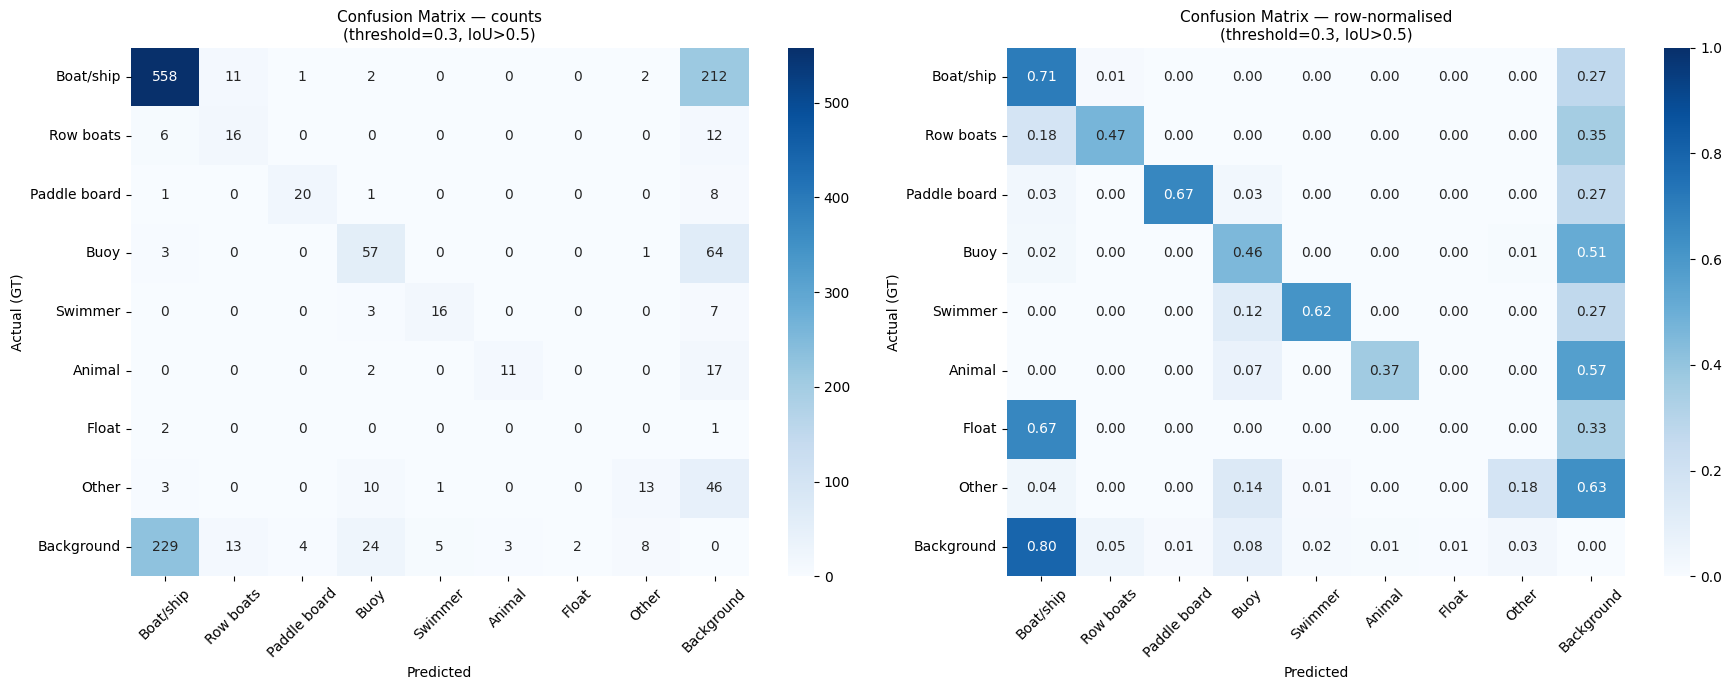

In [24]:
labels_bg = CLASS_NAMES + ["Background"]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Raw counts
ax = axes[0]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_bg, yticklabels=labels_bg, ax=ax)
ax.set_title(f"Confusion Matrix — counts\n(threshold={THRESHOLD}, IoU>{IOU_THRESH})", fontsize=11)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual (GT)")
ax.tick_params(axis="x", rotation=45)

# Row-normalised (recall per class)
cm_norm    = cm.astype(float)
row_sums   = cm_norm.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
cm_norm   /= row_sums

ax = axes[1]
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=labels_bg, yticklabels=labels_bg, ax=ax, vmin=0, vmax=1)
ax.set_title(f"Confusion Matrix — row-normalised\n(threshold={THRESHOLD}, IoU>{IOU_THRESH})", fontsize=11)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual (GT)")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(RUNS_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [25]:
# Per-class precision and recall derived from the confusion matrix
print(f"{'Class':<20} {'TP':>5} {'FN':>5} {'FP':>5} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("-" * 65)
for i, name in enumerate(CLASS_NAMES):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp    # all GT i not predicted as i
    fp = cm[:, i].sum() - tp    # all predictions of i that aren't GT i
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    print(f"{name:<20} {tp:>5} {fn:>5} {fp:>5} {prec:>10.3f} {rec:>8.3f} {f1:>8.3f}")

Class                   TP    FN    FP  Precision   Recall       F1
-----------------------------------------------------------------
Boat/ship              558   228   244      0.696    0.710    0.703
Row boats               16    18    24      0.400    0.471    0.432
Paddle board            20    10     5      0.800    0.667    0.727
Buoy                    57    68    42      0.576    0.456    0.509
Swimmer                 16    10     6      0.727    0.615    0.667
Animal                  11    19     3      0.786    0.367    0.500
Float                    0     3     2      0.000    0.000    0.000
Other                   13    60    11      0.542    0.178    0.268


---
## 4. Misclassification Visualizations

Three types of errors are visualised:
- **Wrong-class predictions** — model detected an object at the right location (IoU ≥ 0.5) but assigned the wrong category.
- **False positives** — model predicted an object that has no corresponding GT box.
- **False negatives** — GT object that the model completely missed.

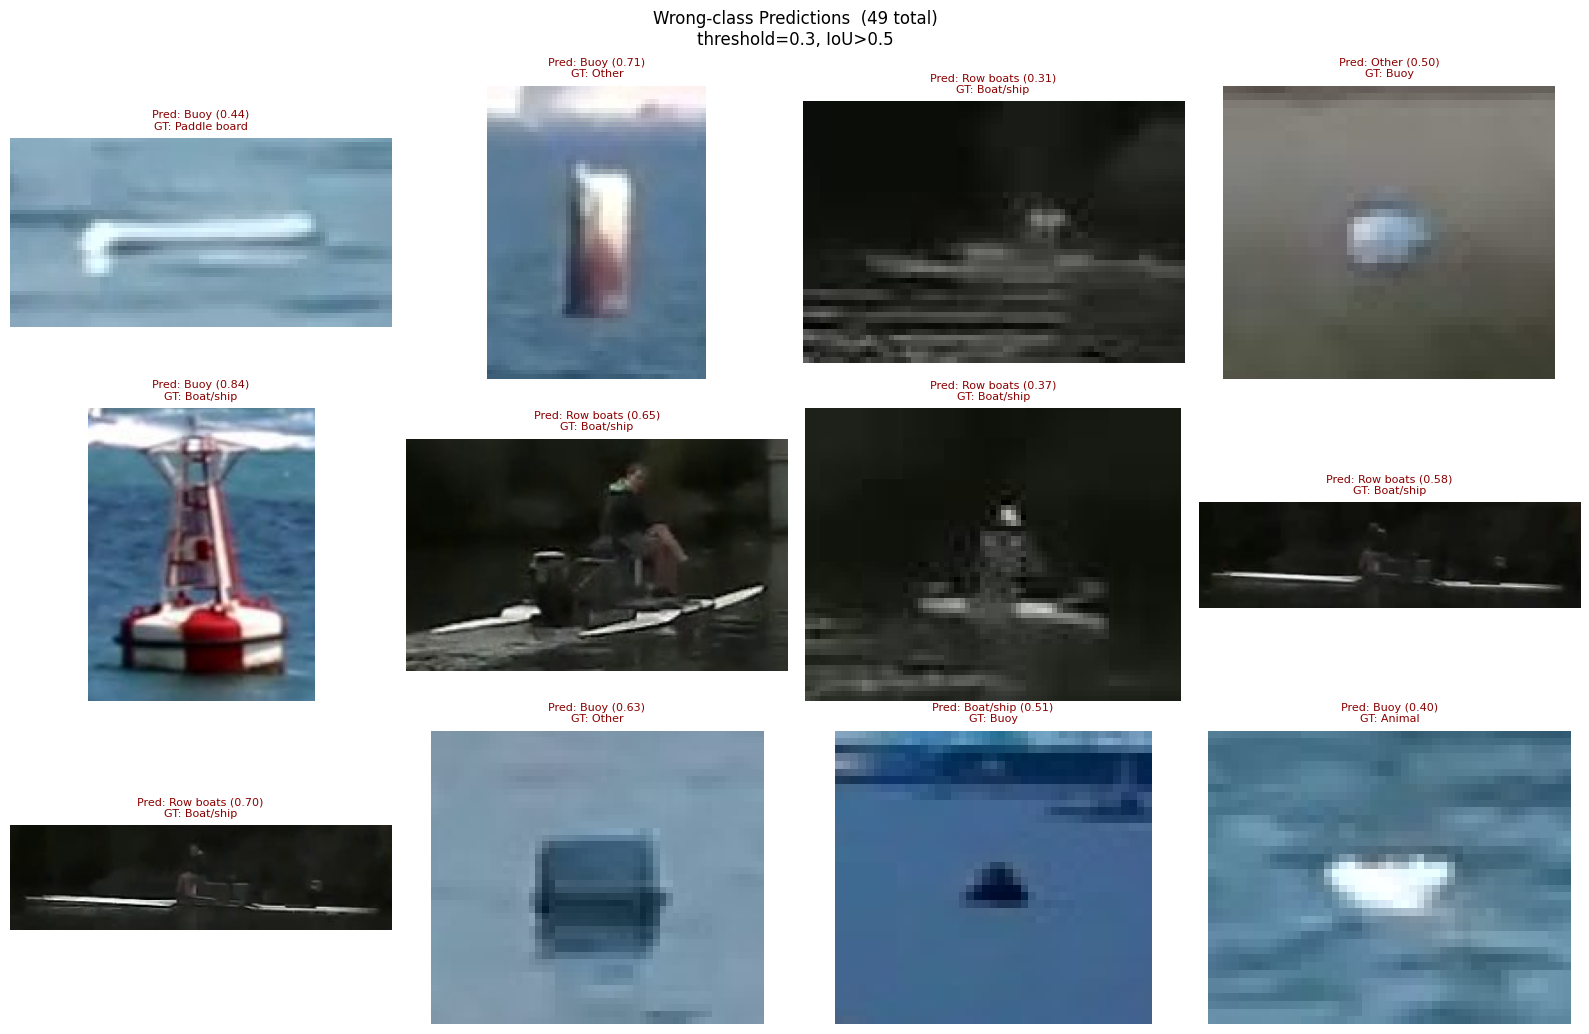

Showing 12 of 49 wrong-class predictions.


In [26]:
def crop_box(arr, box, pad=15):
    """Crop a padded region around a xyxy bounding box."""
    h, w = arr.shape[:2]
    x1, y1, x2, y2 = int(box[0]), int(box[1]), int(box[2]), int(box[3])
    return arr[max(0, y1-pad):min(h, y2+pad), max(0, x1-pad):min(w, x2+pad)]


n_show = min(12, len(wrong_class_examples))
if n_show == 0:
    print("No wrong-class predictions found at this threshold / IoU setting.")
else:
    random.seed(4)
    samples = random.sample(wrong_class_examples, n_show)
    cols = 4
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
    axes = np.array(axes).reshape(-1)

    for ax, (img_path, pred_box, pred_cls, pred_score, gt_box, gt_cls) in zip(axes, samples):
        arr  = np.array(Image.open(img_path).convert("RGB"))
        crop = crop_box(arr, pred_box)
        ax.imshow(crop)
        ax.set_title(
            f"Pred: {pred_class_name(pred_cls)} ({pred_score:.2f})\nGT: {gt_class_name(gt_cls)}",
            fontsize=8, color="darkred"
        )
        ax.axis("off")

    for ax in axes[n_show:]:
        ax.axis("off")

    plt.suptitle(
        f"Wrong-class Predictions  ({len(wrong_class_examples)} total)\n"
        f"threshold={THRESHOLD}, IoU>{IOU_THRESH}",
        fontsize=12
    )
    plt.tight_layout()
    plt.savefig(RUNS_DIR / "wrong_class.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Showing {n_show} of {len(wrong_class_examples)} wrong-class predictions.")

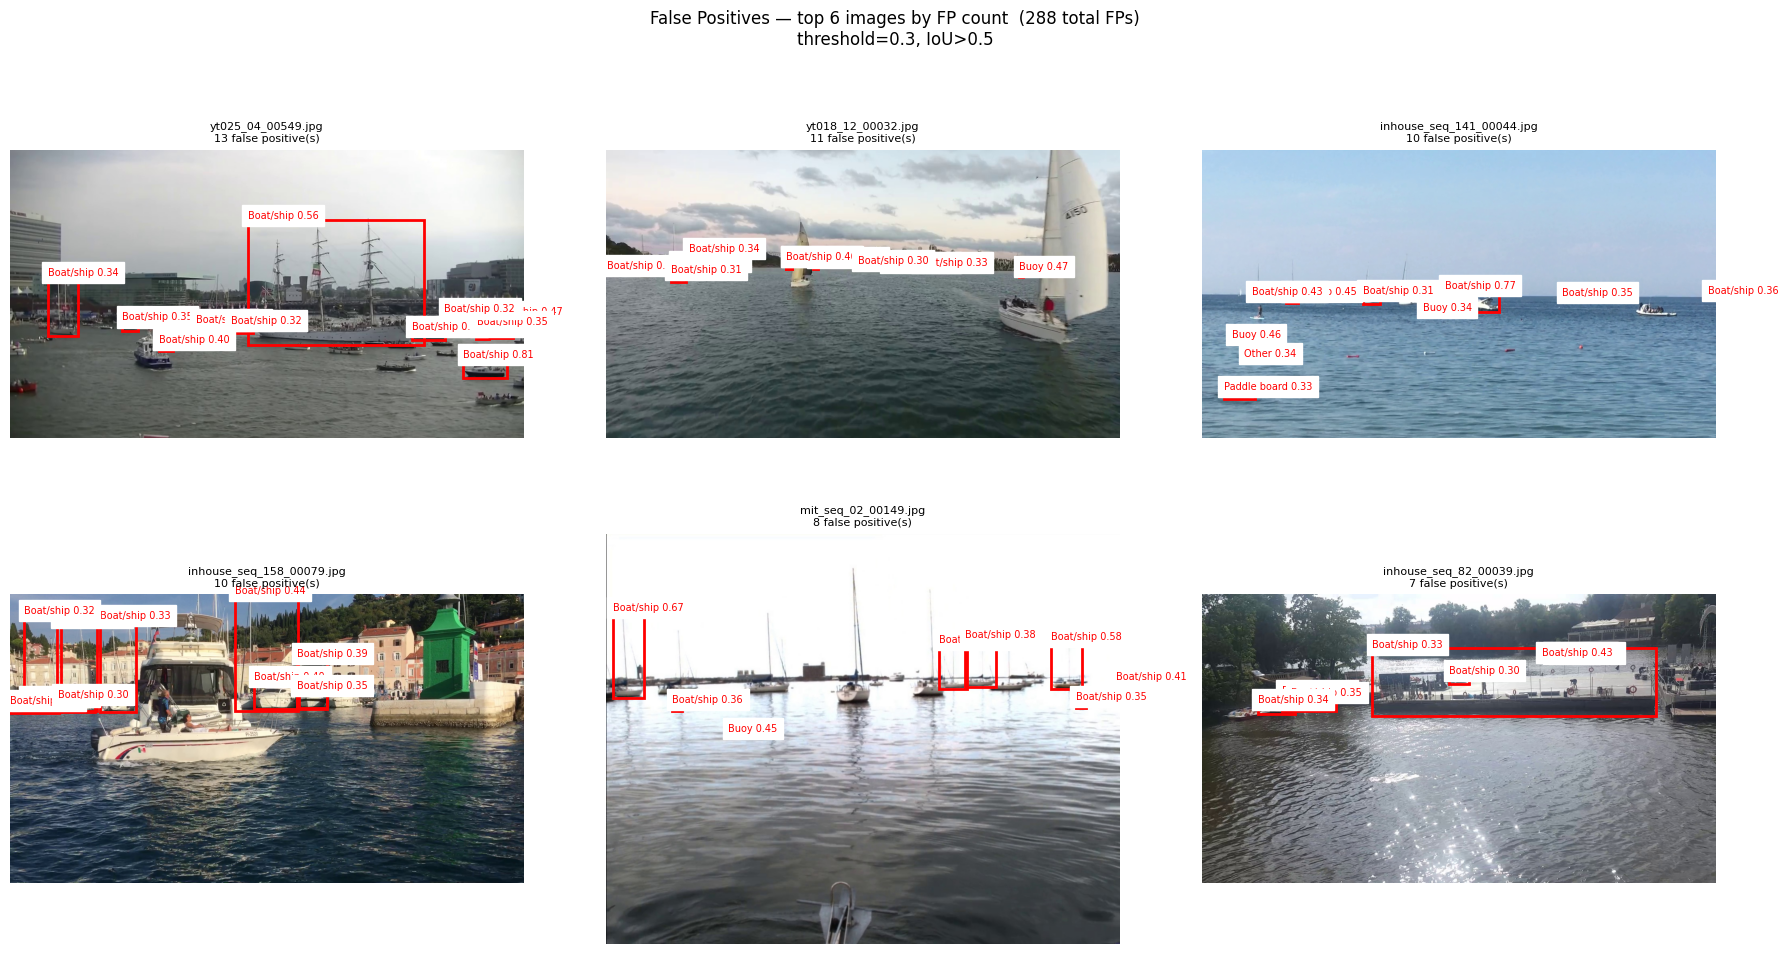

In [27]:
# Show the 6 images with the most false positives
fp_sorted = sorted(fp_by_image.items(), key=lambda x: -len(x[1]))
n_show    = min(6, len(fp_sorted))

if n_show == 0:
    print("No false positives found at this threshold / IoU setting.")
else:
    cols = 3
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 5))
    axes = np.array(axes).reshape(-1)

    for ax, (img_path, fp_list) in zip(axes, fp_sorted[:n_show]):
        arr = np.array(Image.open(img_path).convert("RGB"))
        ax.imshow(arr)
        for (box, cls, score) in fp_list:
            x1, y1, x2, y2 = box
            rect = mpatches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2, edgecolor="red", facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(x1, y1 - 3, f"{pred_class_name(cls)} {score:.2f}",
                    color="red", fontsize=7, backgroundcolor="white")
        ax.set_title(f"{img_path.name}\n{len(fp_list)} false positive(s)", fontsize=8)
        ax.axis("off")

    for ax in axes[n_show:]:
        ax.axis("off")

    total_fp = sum(len(v) for v in fp_by_image.values())
    plt.suptitle(
        f"False Positives — top {n_show} images by FP count  ({total_fp} total FPs)\n"
        f"threshold={THRESHOLD}, IoU>{IOU_THRESH}",
        fontsize=12
    )
    plt.tight_layout()
    plt.savefig(RUNS_DIR / "false_positives.png", dpi=150, bbox_inches="tight")
    plt.show()

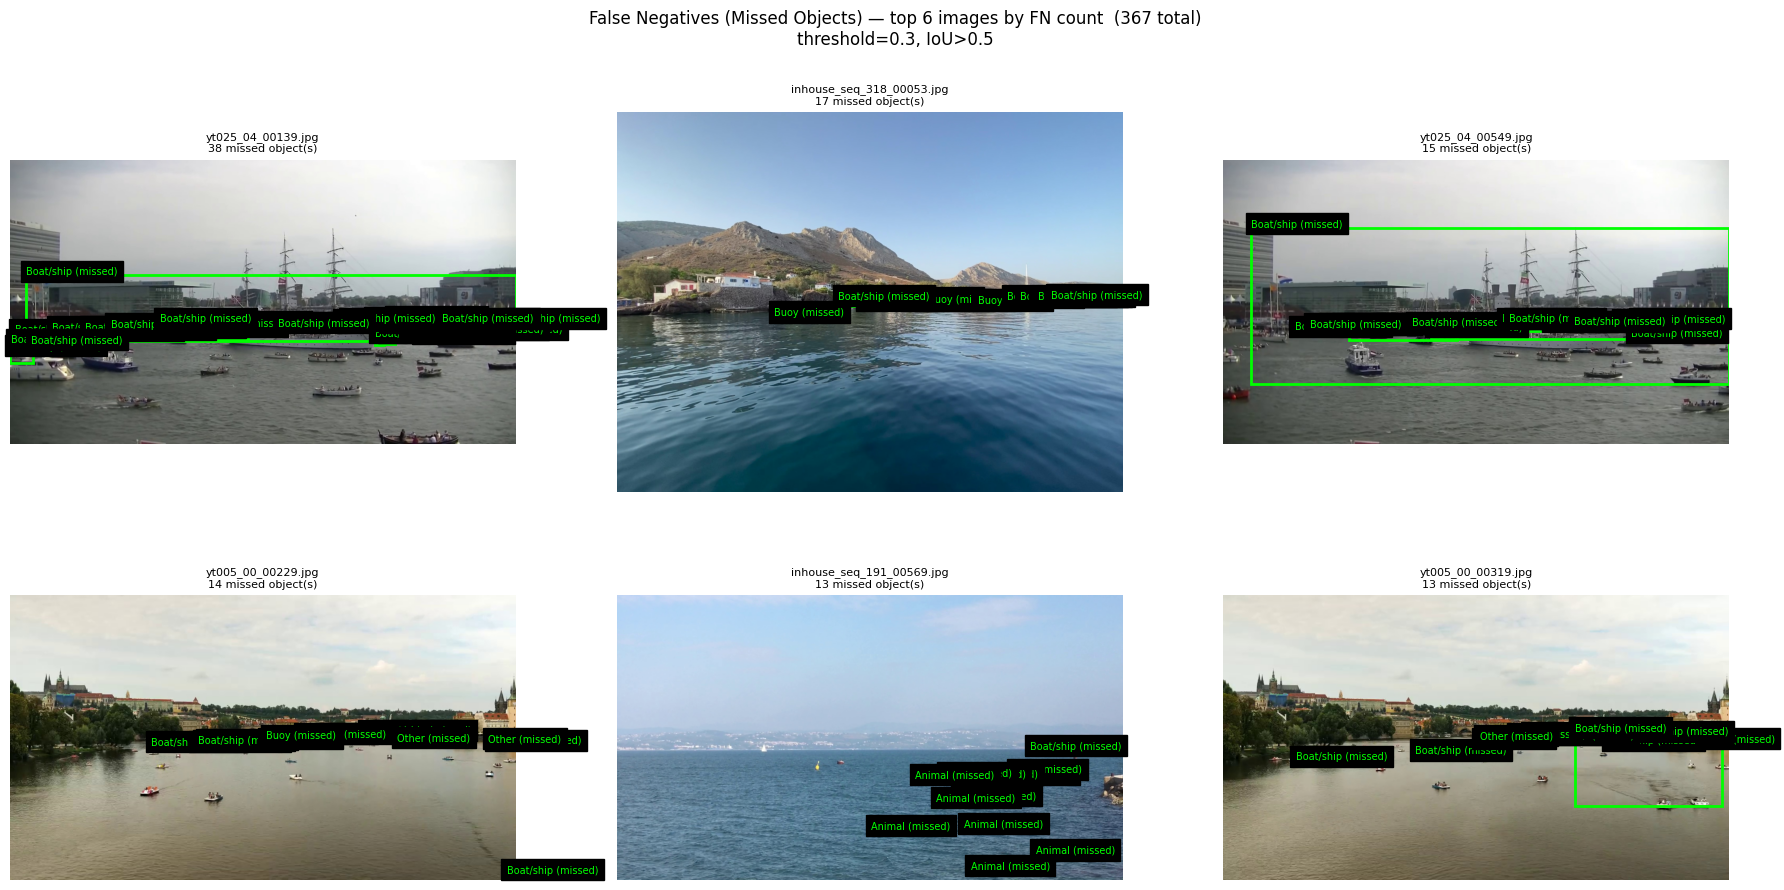

In [28]:
# Show the 6 images with the most false negatives (missed objects)
fn_sorted = sorted(fn_by_image.items(), key=lambda x: -len(x[1]))
n_show    = min(6, len(fn_sorted))

if n_show == 0:
    print("No false negatives found at this threshold / IoU setting.")
else:
    cols = 3
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 5))
    axes = np.array(axes).reshape(-1)

    for ax, (img_path, fn_list) in zip(axes, fn_sorted[:n_show]):
        arr = np.array(Image.open(img_path).convert("RGB"))
        ax.imshow(arr)
        for (box, cls) in fn_list:
            x1, y1, x2, y2 = box
            rect = mpatches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2, edgecolor="lime", facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(x1, y1 - 3, f"{gt_class_name(cls)} (missed)",
                    color="lime", fontsize=7, backgroundcolor="black")
        ax.set_title(f"{img_path.name}\n{len(fn_list)} missed object(s)", fontsize=8)
        ax.axis("off")

    for ax in axes[n_show:]:
        ax.axis("off")

    total_fn = sum(len(v) for v in fn_by_image.values())
    plt.suptitle(
        f"False Negatives (Missed Objects) — top {n_show} images by FN count  ({total_fn} total)\n"
        f"threshold={THRESHOLD}, IoU>{IOU_THRESH}",
        fontsize=12
    )
    plt.tight_layout()
    plt.savefig(RUNS_DIR / "false_negatives.png", dpi=150, bbox_inches="tight")
    plt.show()